In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# OOD performance

In [16]:
df_base_path = '../results'

In [17]:
# Load your three dataframes
baseline_df = pd.read_csv(f"{df_base_path}/baseline_by_celltype_correlations.csv")
cellina_df = pd.read_csv(f"{df_base_path}/cellina_by_celltype_correlations.csv")
cpa_df = pd.read_csv(f"{df_base_path}/cpa_by_celltype_correlations.csv")

# remove epithelial row from cpa
cpa_df = cpa_df[cpa_df['celltype'] != 'Epithelial']

# Add a column to identify the source dataframe
baseline_df['method'] = 'baseline'
cpa_df['method'] = 'cpa'
cellina_df['method'] = 'cellina'

# Combine them
df_all = pd.concat([baseline_df, cpa_df, cellina_df], ignore_index=True)

# Melt the dataframe so we can plot pearson and spearman separately
df_melt = df_all.melt(id_vars=['celltype', 'method'], value_vars=['pearson', 'spearman'],
                      var_name='correlation', value_name='value')

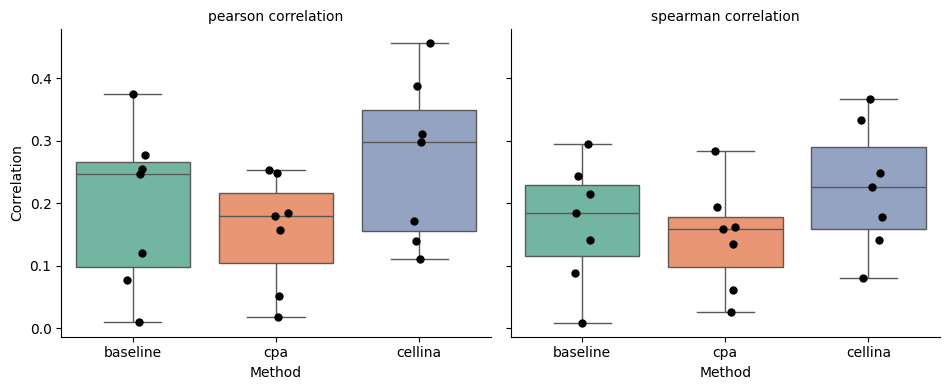

In [18]:
g = sns.catplot(
    data=df_melt, kind="box",
    x="method", y="value", hue="method",
    col="correlation",  # separate plots for pearson and spearman
    dodge=False, palette="Set2",
    height=4, aspect=1.2
)

# Add the individual points (dots) for each cell type
for ax, corr_type in zip(g.axes[0], ['pearson', 'spearman']):
    sns.stripplot(
        data=df_melt[df_melt['correlation']==corr_type],
        x='method', y='value', color='black', size=6, ax=ax, jitter=True
    )

g.set_axis_labels("Method", "Correlation")
g.set_titles("{col_name} correlation")
plt.show()

# LFC agreement between observed and reconstructed counts

In [19]:
cellina_de = pd.read_csv(f"{df_base_path}/cellina_de.csv", index_col=0).T
cpa_de = pd.read_csv(f"{df_base_path}/cpa_de.csv", index_col=0).T

In [20]:
cpa_de.index.name = "celltype"
cellina_de.index.name = "celltype"

/tmp/ipykernel_2026619/1853090153.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,


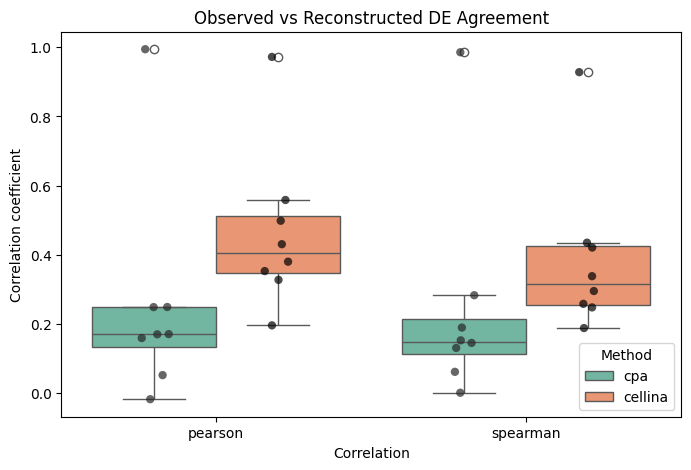

In [21]:
# Add a column to identify the source dataframe
cpa_de['method'] = 'cpa'
cellina_de['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_de, cellina_de])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Correlation", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Correlation", y="Value", hue="method", data=df_melted, palette="Set2")
sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Observed vs Reconstructed DE Agreement")
plt.ylabel("Correlation coefficient")
plt.show()

# E-distances between observed and reconstructed cells

In [22]:
cellina_edist = pd.read_csv(f"{df_base_path}/cellina_edist.csv", index_col=0)
cpa_edist = pd.read_csv(f"{df_base_path}/cpa_edist.csv", index_col=0)

In [23]:
cpa_edist.index.name = "celltype"
cellina_edist.index.name = "celltype"

/tmp/ipykernel_2026619/1993656564.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,


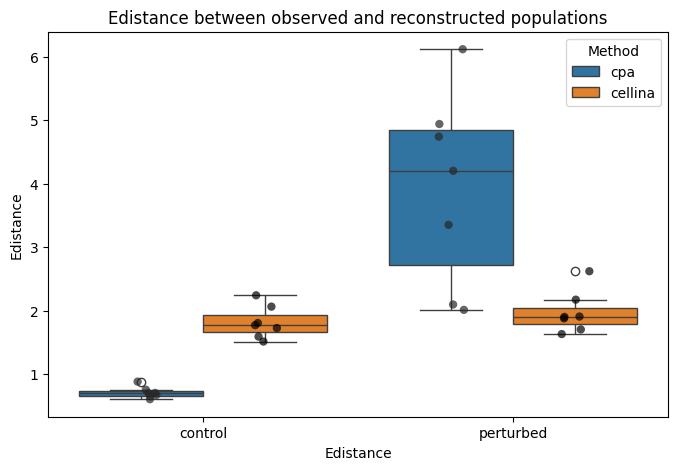

In [24]:
# Add a column to identify the source dataframe
cpa_edist['method'] = 'cpa'
cellina_edist['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_edist, cellina_edist])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Edistance", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Edistance", y="Value", hue="method", data=df_melted, palette="tab10")
sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Edistance between observed and reconstructed populations")
plt.ylabel("Edistance")
plt.show()

# LOO plots

In [6]:
import os
import glob
import json

corr_dir = "/data2/a330d/datasets/crc/correlations"
pattern = os.path.join(corr_dir, "crc_*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    if not name.startswith("crc_") or not name.endswith(".json"):
        continue
    core = name[len("crc_"):-len(".json")]
    parts = core.split("_")
    if len(parts) < 3:
        # unexpected filename, skip
        continue
    sid = parts[0]
    model_name = parts[1] 
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue
    rows.append({
        "sid": sid,
        "model_name": model_name,
        "holdout_celltype": holdout_celltype,
        "spearman": data.get("spearman"),
        "pearson": data.get("pearson"),
    })

crc_corr_df = pd.DataFrame(rows, columns=["sid", "model_name", "holdout_celltype", "spearman", "pearson"])
crc_corr_df

,sid,model_name,holdout_celltype,spearman,pearson
0,210,baseline,Endothelial,0.261815,0.391285
1,210,baseline,Fibroblast,0.211284,0.227767
2,210,baseline,Myeloid,0.420708,0.365960
3,210,baseline,T_cell,0.245525,0.276844
4,210,cellina-ablated,Endothelial,0.559339,0.597404
5,210,cellina-ablated,Fibroblast,0.334959,0.387329
6,210,cellina-ablated,Myeloid,0.463298,0.417457
7,210,cellina-ablated,T_cell,0.704903,0.699715
8,210,cellina-graph,Endothelial,-0.071571,-0.060200
9,210,cellina-graph,Fibroblast,-0.104289,-0.154629


/tmp/ipykernel_3034307/3120514377.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_3034307/3120514377.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


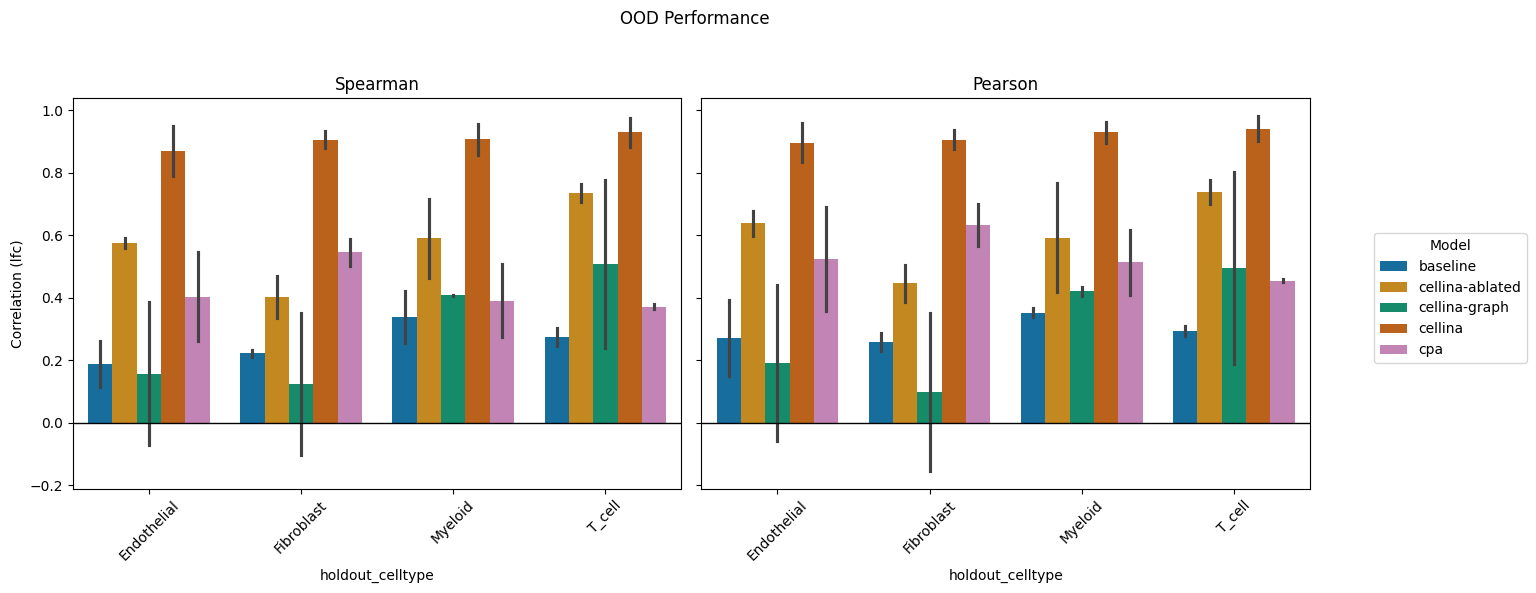

In [7]:
# plot both Spearman and Pearson side-by-side, larger figure, legend moved outside
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

palette = "colorblind"
sns.barplot(
    data=crc_corr_df, x="holdout_celltype", y="spearman", hue="model_name",
    ax=axes[0], palette=palette, #ci=None
)
axes[0].set_title("Spearman")
axes[0].set_ylabel("Correlation (lfc)")

sns.barplot(
    data=crc_corr_df, x="holdout_celltype", y="pearson", hue="model_name",
    ax=axes[1], palette=palette, #ci=None
)
axes[1].set_title("Pearson")
axes[1].set_ylabel("")

# remove per-axes legends and place a single legend on the right
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Model", bbox_to_anchor=(0.98, 0.5), loc="center left")

# horizontal zero line on both panels, rotate xticks and tidy layout
for ax in axes:
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

fig.suptitle("OOD Performance")
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()